In [5]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict
from dotenv import load_dotenv
import os

In [6]:
load_dotenv()

True

In [7]:
api_key = os.getenv("OPEN_AI_KEY")

In [16]:
llm = ChatOpenAI(
    api_key=api_key,
    base_url="https://openrouter.ai/api/v1"
)

In [17]:
class BlogState(TypedDict):
    title: str
    outline: str
    content: str
    

In [18]:
def create_outline(state: BlogState) -> BlogState:
    title = state['title']

    prompt = f"create me outline for this title: {title}"

    outline = llm.invoke(prompt).content

    state['outlint'] = outline

    return state


In [19]:
def create_blog(state: BlogState) -> BlogState:
    title: state['title']
    outline: state['outline']

    prompt = f"Write me blog for this title: {title} \n here is helpful outlines {outline}"

    content = llm.invoke(prompt).content

    state['content'] = content
    
    return state    

In [20]:
# define a graph
graph = StateGraph(BlogState)

# add the nodes
graph.add_node("create_outline", create_outline)
graph.add_node("create_blog", create_blog)

# add edges
graph.add_edge(START, "create_outline")
graph.add_edge("create_outline", "create_blog")
graph.add_edge("create_blog", END)

# compile graph
workflow = graph.compile()



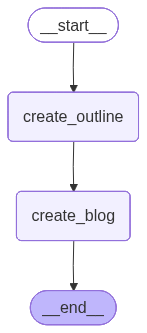

In [21]:
workflow

In [22]:
initial_state = {"title": "AI"}
final_state = workflow.invoke(initial_state)

AuthenticationError: Error code: 401 - {'error': {'message': 'User not found.', 'code': 401}}

In [ ]:
final_state